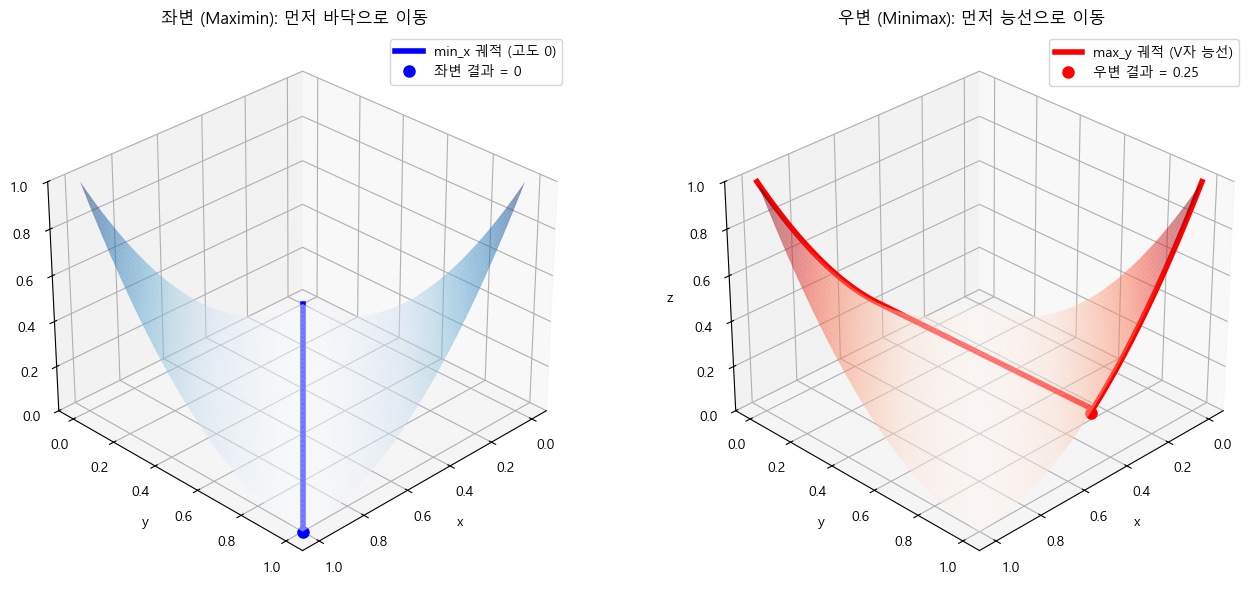

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig = plt.figure(figsize=(14, 6))

# 데이터 생성
x = np.linspace(0, 1, 50)
y = np.linspace(0, 1, 50)
X, Y = np.meshgrid(x, y)
Z = (X - Y)**2

# 1. 좌변: Maximin (y단면 최저점들의 집합) 시각화
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, Z, cmap='Blues', alpha=0.5, edgecolor='none')

# 각 y단면에서의 x 최저점 궤적 (골짜기 바닥)
min_x_path_X = y
min_x_path_Y = y
min_x_path_Z = np.zeros_like(y)
ax1.plot(min_x_path_X, min_x_path_Y, min_x_path_Z, color='blue', linewidth=4, label='min_x 궤적 (고도 0)')
ax1.plot([1], [1], [0], 'bo', markersize=8, label='좌변 결과 = 0')

ax1.set_title('좌변 (Maximin): 먼저 바닥으로 이동')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')
ax1.set_zlim(0, 1)
ax1.view_init(elev=30, azim=45)
ax1.legend()

# 2. 우변: Minimax (x단면 최고점들의 집합) 시각화
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, Z, cmap='Reds', alpha=0.5, edgecolor='none')

# 각 x단면에서의 y 최고점 궤적 (V자 능선)
max_y_path_X = x
max_y_path_Y = np.where(x > 0.5, 0, 1)
max_y_path_Z = np.maximum(x**2, (1-x)**2)
ax2.plot(max_y_path_X, max_y_path_Y, max_y_path_Z, color='red', linewidth=4, label='max_y 궤적 (V자 능선)')
ax2.plot([0.5], [1], [0.25], 'ro', markersize=8, label='우변 결과 = 0.25')

ax2.set_title('우변 (Minimax): 먼저 능선으로 이동')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('z')
ax2.set_zlim(0, 1)
ax2.view_init(elev=30, azim=45)
ax2.legend()

plt.tight_layout()
plt.show()

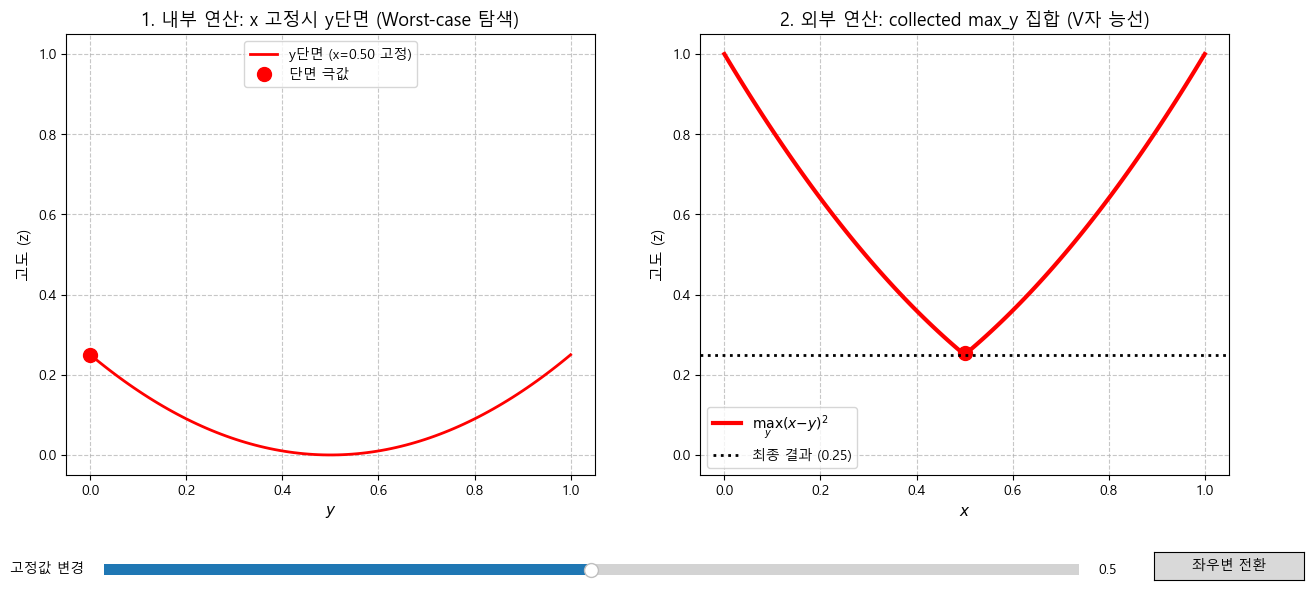

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

# 한글 폰트 설정 (Windows/Mac 호환성 확보)
import platform
system_os = platform.system()
if system_os == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif system_os == 'Darwin': # Mac
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 데이터 및 시각화 기본 설정
# ==========================================
# 정의역 설정 (0 ~ 1)
u_mesh = np.linspace(0, 1, 100)
function_phi = lambda x, y: (x - y)**2

# 그래프 레이아웃 설정 (1x2 Subplots)
fig, (ax_slice, ax_ridge) = plt.subplots(1, 2, figsize=(15, 7))
plt.subplots_adjust(bottom=0.25) # 슬라이더 공간 확보

# 초기 고정값 설정
init_fixed_val = 0.5
mode = 'minmax' # 초기 모드: 우변(미니맥스)

# ==========================================
# 2. 핵심 함수: Slicing 및 Ridge 계산
# ==========================================
def get_data(fixed_val, mode):
    if mode == 'minmax':
        # 우변: min_x [ max_y (x-y)^2 ]
        # 내부 연산: x를 고정하고 y에 대해 max 탐색
        x_fixed = fixed_val
        slice_y = u_mesh
        slice_z = function_phi(x_fixed, slice_y)
        
        # y단면에서의 최댓값( worst case ) 탐색
        extremum_idx = np.argmax(slice_z)
        slice_extremum = (slice_y[extremum_idx], slice_z[extremum_idx])
        
        # 외부 연산 대상 (V자 능선 전체) 계산: h(x) = max(x^2, (1-x)^2)
        ridge_x = u_mesh
        ridge_z = np.maximum(ridge_x**2, (1-ridge_x)**2)
        # 현재 슬라이더 위치에 해당하는 능선 상의 점
        current_ridge_point = (x_fixed, ridge_z[int(x_fixed*99)])
        
        titles = ('1. 내부 연산: x 고정시 y단면 (Worst-case 탐색)',
                  '2. 외부 연산: collected max_y 집합 (V자 능선)')
        labels = (f'y단면 (x={x_fixed:.2f} 고정)', '$\max_y (x-y)^2$', '$x$', '$y$')
        
    else:
        # 좌변: max_y [ min_x (x-y)^2 ]
        # 내부 연산: y를 고정하고 x에 대해 min 탐색
        y_fixed = fixed_val
        slice_x = u_mesh
        slice_z = function_phi(slice_x, y_fixed)
        
        # x단면에서의 최솟값( best case ) 탐색
        extremum_idx = np.argmin(slice_z)
        slice_extremum = (slice_x[extremum_idx], slice_z[extremum_idx])
        
        # 외부 연산 대상 (골짜기 바닥 전체) 계산: g(y) = 0
        ridge_y = u_mesh
        ridge_z = np.zeros_like(ridge_y)
        # 현재 슬라이더 위치에 해당하는 바닥 상의 점
        current_ridge_point = (y_fixed, 0)
        
        titles = ('1. 내부 연산: y 고정시 x단면 (Best-case 탐색)',
                  '2. 외부 연산: collected min_x 집합 (골짜기 바닥)')
        labels = (f'x단면 (y={y_fixed:.2f} 고정)', '$\min_x (x-y)^2$', '$y$', '$x$')

    return slice_y, slice_z, slice_extremum, ridge_x if mode=='minmax' else ridge_y, ridge_z, current_ridge_point, titles, labels

# ==========================================
# 3. 초기 그래프 렌더링
# ==========================================
slice_y, slice_z, slice_extremum, ridge_u, ridge_z, current_ridge_point, titles, labels = get_data(init_fixed_val, mode)

# 왼쪽: 단면 그래프
line_slice, = ax_slice.plot(slice_y, slice_z, color='red', linewidth=2, label=labels[0])
point_extremum, = ax_slice.plot(slice_extremum[0], slice_extremum[1], 'ro', markersize=10, label='단면 극값')
ax_slice.set_title(titles[0], fontsize=13)
ax_slice.set_xlabel(labels[3], fontsize=11)
ax_slice.set_ylabel('고도 (z)', fontsize=11)
ax_slice.set_ylim(-0.05, 1.05)
ax_slice.grid(True, linestyle='--', alpha=0.7)
ax_slice.legend(loc='upper center')

# 오른쪽: 능선/골짜기 그래프
line_ridge, = ax_ridge.plot(ridge_u, ridge_z, color='red', linewidth=3, label=labels[1])
point_current_ridge, = ax_ridge.plot(current_ridge_point[0], current_ridge_point[1], 'ro', markersize=10)
# 최종 결과값 라인 (0.25 또는 0)
line_final_result = ax_ridge.axhline(y=0.25, color='black', linestyle=':', linewidth=2, label='최종 결과 (0.25)')

ax_ridge.set_title(titles[1], fontsize=13)
ax_ridge.set_xlabel(labels[2], fontsize=11)
ax_ridge.set_ylabel('고도 (z)', fontsize=11)
ax_ridge.set_ylim(-0.05, 1.05)
ax_ridge.grid(True, linestyle='--', alpha=0.7)
ax_ridge.legend()

# ==========================================
# 4. 상호작용 요소 (Slider & Button)
# ==========================================
# 슬라이더 추가
ax_slider = plt.axes([0.15, 0.1, 0.65, 0.03])
slider = Slider(ax_slider, '고정값 변경', 0.0, 1.0, valinit=init_fixed_val, valstep=0.01)

# 업데이트 함수
def update(val):
    current_fixed = slider.val
    slice_u, slice_z, slice_extremum, ridge_u, ridge_z, current_ridge_point, _, labels = get_data(current_fixed, mode)
    
    # 데이터 업데이트
    line_slice.set_xdata(slice_u)
    line_slice.set_ydata(slice_z)
    line_slice.set_label(labels[0])
    point_extremum.set_data(slice_extremum[0], slice_extremum[1])
    
    line_ridge.set_xdata(ridge_u)
    line_ridge.set_ydata(ridge_z)
    line_ridge.set_label(labels[1])
    point_current_ridge.set_data(current_ridge_point[0], current_ridge_point[1])
    
    # 범례 업데이트 (라벨 변경 반영)
    ax_slice.legend(loc='upper center')
    ax_ridge.legend()
    fig.canvas.draw_idle()

slider.on_changed(update)

# 모드 전환 버튼 추가
from matplotlib.widgets import Button
ax_button = plt.axes([0.85, 0.1, 0.1, 0.04])
button = Button(ax_button, '좌우변 전환')

def switch_mode(event):
    global mode
    if mode == 'minmax':
        mode = 'maxmin'
        ax_slice.set_title(get_data(slider.val, mode)[6][0])
        point_extremum.set_color('blue')
        line_slice.set_color('blue')
        line_ridge.set_color('blue')
        point_current_ridge.set_color('blue')
        line_final_result.set_ydata(0)
        line_final_result.set_label('최종 결과 (0)')
    else:
        mode = 'minmax'
        point_extremum.set_color('red')
        line_slice.set_color('red')
        line_ridge.set_color('red')
        point_current_ridge.set_color('red')
        line_final_result.set_ydata(0.25)
        line_final_result.set_label('최종 결과 (0.25)')
        
    update(slider.val) # 모드 전환 후 그래프 갱신
    ax_ridge.set_title(get_data(slider.val, mode)[6][1])

button.on_clicked(switch_mode)

plt.show()